<a href="https://colab.research.google.com/github/VictorMorais777/Disciplina-de-Inteligencia-Artificial/blob/main/FISHMORPH_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Importar


In [2]:
import pandas as pd

df = pd.read_csv('/FISHMORPH_Family_Dataset.csv')

df.head()


,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Family
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,Cyprinidae
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,Cichlidae
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,Cyprinidae
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,Cyprinidae
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,Cyprinidae


2. análise padrão


In [6]:
df.info()
df.isna().sum()
df.duplicated().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8342 entries, 0 to 8341
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MBl     8342 non-null   float64
 1   BEl     8342 non-null   float64
 2   VEp     8342 non-null   float64
 3   REs     8342 non-null   float64
 4   OGp     8342 non-null   float64
 5   RMl     8342 non-null   float64
 6   BLs     8342 non-null   float64
 7   PFv     8342 non-null   float64
 8   PFs     8342 non-null   float64
 9   CPt     8342 non-null   float64
 10  Family  8342 non-null   object 
dtypes: float64(10), object(1)
memory usage: 717.0+ KB


,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt
count,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000
mean,22.004517,4.452438,0.549087,0.391665,0.381768,0.399786,0.571818,0.285316,0.189343,2.560795
std,33.612007,2.338235,0.094883,0.132814,0.194352,0.302658,0.117486,0.155629,0.056109,1.016659
min,1.200000,1.033084,0.159248,0.000000,0.000000,0.000000,0.224525,0.000000,0.000000,0.000000
25%,7.000000,3.139102,0.487993,0.293205,0.278014,0.257999,0.490052,0.193134,0.157972,1.999744
50%,12.600000,4.038851,0.546213,0.389429,0.406904,0.361436,0.564739,0.275039,0.183497,2.436329
75%,24.500000,5.002621,0.605125,0.486221,0.516001,0.490671,0.648039,0.368876,0.215031,2.919818
max,800.000000,43.728161,1.000000,1.026667,1.026316,7.060344,1.230105,0.857097,0.511113,15.452061


3. Tratar Duplicatas

In [8]:
df = df.drop_duplicates()

4. Distribuição das categorias

Family
Cyprinidae        1545
Cichlidae         1060
Characidae         732
Loricariidae       427
Percidae           190
Gobiidae           187
Callichthyidae     159
Rivulidae          158
Poeciliidae        154
Nemacheilidae      145
Mormyridae         138
Mochokidae         137
Bagridae           129
Cobitidae          108
Heptapteridae      106
Name: count, dtype: int64


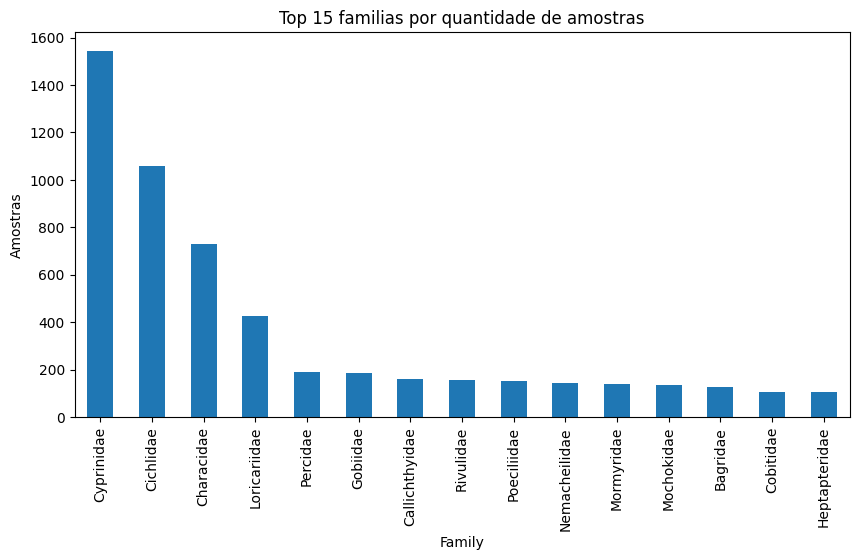

In [9]:
import matplotlib.pyplot as plt

contagem = df['Family'].value_counts()
print(contagem.head(15))

contagem.head(15).plot(kind='bar', figsize=(10, 5))
plt.title('Top 15 familias por quantidade de amostras')
plt.ylabel('Amostras')
plt.show()


In [10]:
top = contagem.head(10).index
df_f = df[df['Family'].isin(top)]

5. Divisão treino/teste e cross validation

In [11]:
from sklearn.model_selection import train_test_split

X = df_f.drop(columns='Family')
y = df_f['Family']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

6. Grid Search

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

param_grid = {
    'svc__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=1, verbose=1)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svc', SVC())]),
             n_jobs=1,
             param_grid={'svc__C': [0.1, 1, 10, 100],
                         'svc__gamma': [0.001, 0.01, 0.1, 1],
                         'svc__kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='accuracy', verbose=1)

7. Melhor modelo, parâmetros e acurácia

In [15]:
print('Melhor parametros:', grid.best_params_)
print('Acurácia média (cross validation):', grid.best_score_)

melhor = grid.best_estimator_
print('Acurácia no teste:', melhor.score(X_test, y_test))

Melhor parametros: {'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
Acurácia média (cross validation): 0.8969776609724047
Acurácia no teste: 0.9128151260504201


8. Acurácia e matriz de confusão

Acurácia: 0.9128151260504201
                precision    recall  f1-score   support

Callichthyidae       1.00      0.91      0.95        32
    Characidae       0.90      0.82      0.86       147
     Cichlidae       0.98      0.97      0.97       212
    Cyprinidae       0.89      0.95      0.92       309
      Gobiidae       0.85      0.92      0.88        37
  Loricariidae       0.97      0.98      0.97        85
 Nemacheilidae       0.89      0.83      0.86        29
      Percidae       0.86      0.84      0.85        38
   Poeciliidae       0.90      0.84      0.87        31
     Rivulidae       0.73      0.69      0.71        32

      accuracy                           0.91       952
     macro avg       0.90      0.87      0.88       952
  weighted avg       0.91      0.91      0.91       952



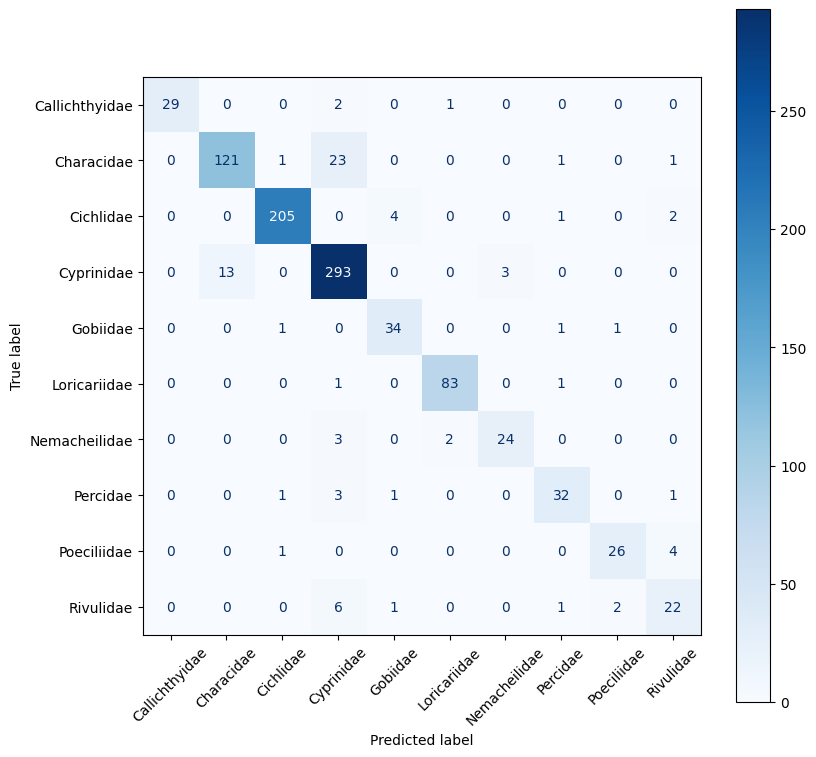

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred = melhor.predict(X_test)
print('Acurácia:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=melhor.classes_)
fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=melhor.classes_).plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.show()